In [8]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pydub import AudioSegment
from scipy.io import wavfile

# Ignorar advertencias de scipy
warnings.filterwarnings('ignore')

# Configuración de nombres de archivos (Rutas locales)
INPUT_AUDIO_PATH = "/home/camila/Documentos/UD/MFC2026-1/Fourier/Tensión/180 C3.mp3"
# OUTPUT_MP3_PATH  = "Cuerda2_libre.mp3"
OUTPUT_WAV_TEMP  = "audio_temp.wav"

if not os.path.exists(INPUT_AUDIO_PATH):
    print(f"❌ Error: No se encuentra '{INPUT_AUDIO_PATH}' en la carpeta actual.")
    print(f"Archivos presentes: {os.listdir('.')}")
else:
    print(f"✅ Archivo listo para procesar: '{INPUT_AUDIO_PATH}'")

✅ Archivo listo para procesar: '/home/camila/Documentos/UD/MFC2026-1/Fourier/Tensión/180 C3.mp3'


In [9]:
# Cargar el archivo de audio original (pydub detecta el formato automáticamente)
print(f" Cargando '{INPUT_AUDIO_PATH}'...")
audio = AudioSegment.from_file(INPUT_AUDIO_PATH)

# Mostrar información del audio cargado
print(f"   ├─ Canales       : {audio.channels} ({'Mono' if audio.channels == 1 else 'Estéreo'})")
print(f"   ├─ Tasa de muestreo: {audio.frame_rate} Hz")
print(f"   ├─ Duración       : {len(audio) / 1000:.2f} segundos")
print(f"   └─ Bits por muestra: {audio.sample_width * 8} bits")

# Exportar también a WAV para poder leer los datos crudos con scipy
audio.export(OUTPUT_WAV_TEMP, format="wav")
print(f" Archivo WAV temporal generado: '{OUTPUT_WAV_TEMP}'")

 Cargando '/home/camila/Documentos/UD/MFC2026-1/Fourier/Tensión/180 C3.mp3'...


   ├─ Canales       : 1 (Mono)
   ├─ Tasa de muestreo: 48000 Hz
   ├─ Duración       : 3.38 segundos
   └─ Bits por muestra: 16 bits
 Archivo WAV temporal generado: 'audio_temp.wav'


In [10]:
# Leer el archivo WAV con scipy para obtener los datos crudos
sample_rate, data = wavfile.read(OUTPUT_WAV_TEMP)

print(f" Tasa de muestreo : {sample_rate} Hz")
print(f" Forma del array  : {data.shape}")
print(f" Tipo de dato     : {data.dtype}")

# Si es estéreo (2 columnas), convertir a mono promediando los canales
if data.ndim == 2:
    print(" Audio estéreo detectado → promediando canales para obtener mono")
    data = data.mean(axis=1)

# Normalizar la señal al rango [-1.0, 1.0]
# El factor de normalización depende del tipo de dato (8, 16 o 32 bits)
max_val = np.iinfo(data.dtype).max if np.issubdtype(data.dtype, np.integer) else 1.0
signal = data.astype(np.float64) / max_val

# Crear el eje de tiempo en segundos
duration = len(signal) / sample_rate
time_axis = np.linspace(0, duration, len(signal))

print(f"\n Señal lista:")
print(f"   ├─ Total de muestras : {len(signal):,}")
print(f"   ├─ Duración          : {duration:.3f} s")
print(f"   └─ Rango normalizado : [{signal.min():.3f}, {signal.max():.3f}]")

 Tasa de muestreo : 48000 Hz
 Forma del array  : (161987,)
 Tipo de dato     : int16

 Señal lista:
   ├─ Total de muestras : 161,987
   ├─ Duración          : 3.375 s
   └─ Rango normalizado : [-0.563, 0.685]


In [11]:
N = len(signal)  # Número total de muestras

# ── Aplicar ventana de Hann para reducir spectral leakage ──────────────────
window   = np.hanning(N)           # Ventana de Hann: suaviza los bordes de la señal
signal_w = signal * window         # Señal ventaneada

# ── Calcular la FFT ────────────────────────────────────────────────────────
fft_result = np.fft.fft(signal_w)  # Array de N números complejos

# ── Magnitud del espectro ──────────────────────────────────────────────────
# |X[k]| da la amplitud de cada componente de frecuencia
# Multiplicamos por 2/N para normalizar (y x2 por quedarnos con mitad)
magnitude = (2 / N) * np.abs(fft_result[:N // 2])

# ── Eje de frecuencias ─────────────────────────────────────────────────────
# fftfreq genera las frecuencias correspondientes a cada bin de la FFT
# d = 1/sample_rate es el intervalo de muestreo en segundos
frequencies = np.fft.fftfreq(N, d=1 / sample_rate)[:N // 2]

# ── Frecuencia dominante ───────────────────────────────────────────────────
idx_max   = np.argmax(magnitude)
freq_dom  = frequencies[idx_max]
mag_max   = magnitude[idx_max]

print(f" FFT calculada sobre {N:,} muestras")
print(f"   ├─ Resolución frecuencial : {sample_rate/N:.4f} Hz por bin")
print(f"   ├─ Frecuencia máxima repr.: {frequencies[-1]:.1f} Hz (Nyquist)")
print(f"   └─ Frecuencia dominante   : {freq_dom:.2f} Hz (magnitud {mag_max:.4f})")

 FFT calculada sobre 161,987 muestras
   ├─ Resolución frecuencial : 0.2963 Hz por bin
   ├─ Frecuencia máxima repr.: 23999.6 Hz (Nyquist)
   └─ Frecuencia dominante   : 416.03 Hz (magnitud 0.0153)


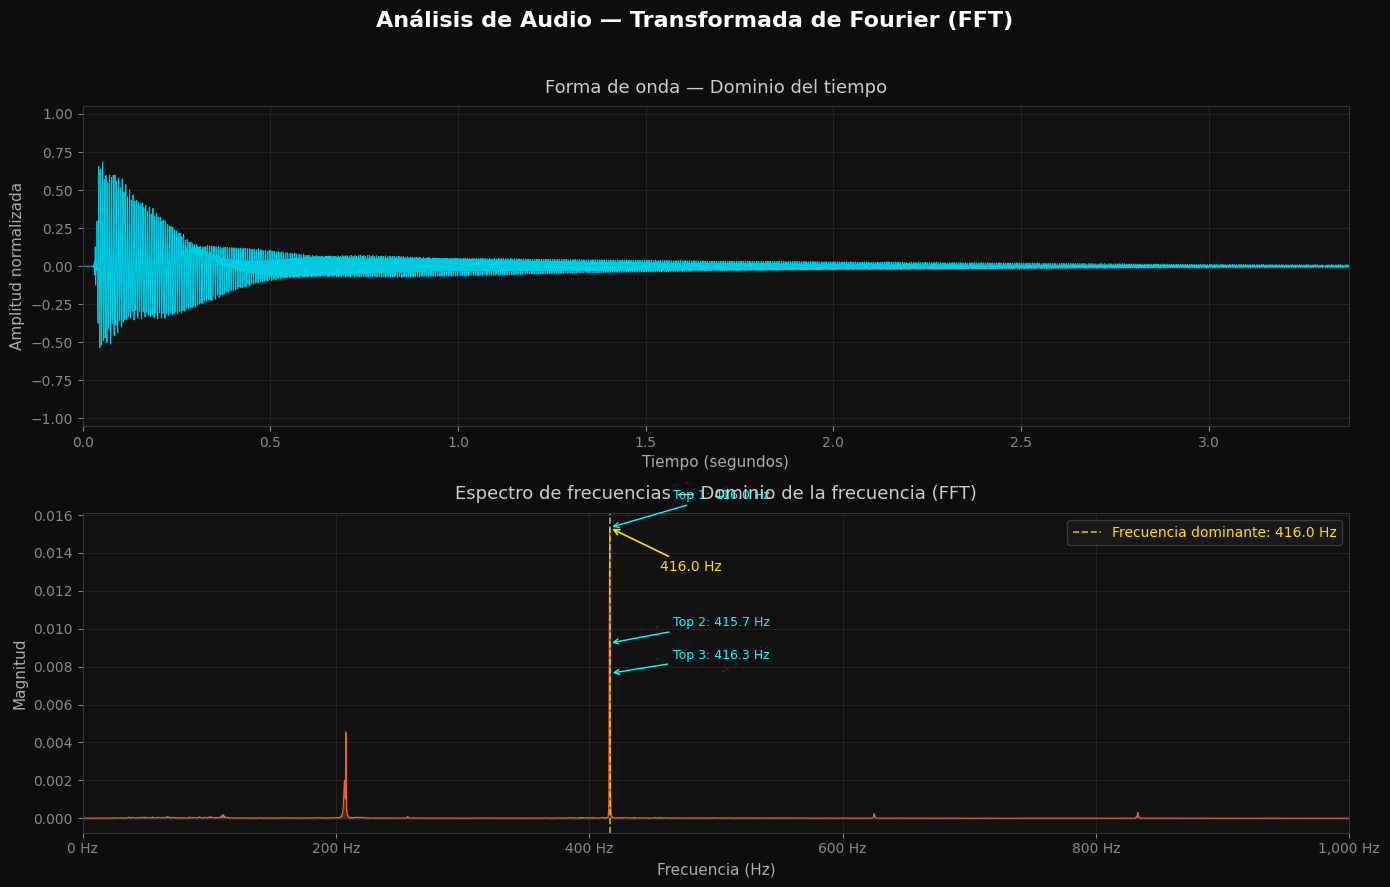

 Gráfica guardada como 'espectro_fourier.png'


In [12]:
%matplotlib inline

import mplcursors

# Limitar la visualización al rango audible humano (20 Hz – 20,000 Hz)
freq_max_plot = min(1000, sample_rate / 2)
mask = frequencies <= freq_max_plot

# ── Configuración estética ─────────────────────────────────────────────────
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 1, figsize=(14, 9), facecolor='#0d0d0d')
fig.suptitle('Análisis de Audio — Transformada de Fourier (FFT)',
             fontsize=16, fontweight='bold', color='white', y=0.98)

# ── Gráfica 1: Señal en el tiempo ─────────────────────────────────────────
ax1 = axes[0]
ax1.set_facecolor('#111111')

# Submuestreamos para no graficar millones de puntos
step = max(1, len(signal) // 10000)
ax1.plot(time_axis[::step], signal[::step],
         color='#00e5ff', linewidth=0.6, alpha=0.85)
ax1.fill_between(time_axis[::step], signal[::step],
                 alpha=0.15, color='#00e5ff')

ax1.set_title('Forma de onda — Dominio del tiempo', fontsize=13,
              color='#cccccc', pad=10)
ax1.set_xlabel('Tiempo (segundos)', color='#aaaaaa', fontsize=11)
ax1.set_ylabel('Amplitud normalizada', color='#aaaaaa', fontsize=11)
ax1.set_xlim([0, duration])
ax1.set_ylim([-1.05, 1.05])
ax1.tick_params(colors='#888888')
ax1.spines[:].set_color('#333333')
ax1.grid(True, color='#2a2a2a', linewidth=0.5)

# ── Gráfica 2: Espectro de frecuencias (FFT) ──────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#111111')

# Store the line object, and enable picker for hover detection
line2, = ax2.plot(frequencies[mask], magnitude[mask],
                 color='#ff6b35', linewidth=0.8, alpha=0.9) # Removed picker=True as it's not supported in inline backend
ax2.fill_between(frequencies[mask], magnitude[mask],
                 alpha=0.25, color='#ff6b35')

# Marcar la frecuencia dominante
ax2.axvline(x=freq_dom, color='#ffdd00', linewidth=1.2,
            linestyle='--', alpha=0.8,
            label=f'Frecuencia dominante: {freq_dom:.1f} Hz')
ax2.annotate(f'{freq_dom:.1f} Hz',
             xy=(freq_dom, mag_max),
             xytext=(freq_dom + freq_max_plot * 0.04, mag_max * 0.85),
             color='#ffdd00', fontsize=10,
             arrowprops=dict(arrowstyle='->', color='#ffdd00', lw=1.2))

# Marcar top 3 frecuencias predominantes
top_indices = np.argsort(magnitude)[::-1][:3]
for i, idx in enumerate(top_indices):
    freq = frequencies[idx]
    mag = magnitude[idx]
    ax2.annotate(f'Top {i+1}: {freq:.1f} Hz',
                 xy=(freq, mag),
                 xytext=(freq + freq_max_plot * 0.05, mag * 1.1),
                 color='cyan', fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='cyan', lw=1))

ax2.set_title('Espectro de frecuencias — Dominio de la frecuencia (FFT)',
              fontsize=13, color='#cccccc', pad=10)
ax2.set_xlabel('Frecuencia (Hz)', color='#aaaaaa', fontsize=11)
ax2.set_ylabel('Magnitud', color='#aaaaaa', fontsize=11)
ax2.set_xlim([0, freq_max_plot])
ax2.tick_params(colors='#888888')
ax2.spines[:].set_color('#333333')
ax2.grid(True, color='#2a2a2a', linewidth=0.5)
ax2.legend(facecolor='#1a1a1a', edgecolor='#444444',
           labelcolor='#ffdd00', fontsize=10)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{int(x):,} Hz'))

# Removed interactive hover annotation code as it relies on interactive backend

# Add hover functionality with mplcursors
cursor = mplcursors.cursor(line2, hover=True)
@cursor.connect("add")
def on_add(sel):
    sel.annotation.set_text(f'{sel.target[0]:.1f} Hz')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('espectro_fourier.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d0d')
plt.show()
print(" Gráfica guardada como 'espectro_fourier.png'")

In [13]:
# ── Centroide espectral ────────────────────────────────────────────────────
# Es la media ponderada de las frecuencias, donde el peso es la magnitud
centroide = np.sum(frequencies * magnitude) / np.sum(magnitude)

# ── Top 5 frecuencias dominantes ──────────────────────────────────────────
top_indices = np.argsort(magnitude)[::-1][:5]
top_freqs   = frequencies[top_indices]
top_mags    = magnitude[top_indices]

# ── Energía por banda ─────────────────────────────────────────────────────
def energia_banda(f_min, f_max):
    """Calcula la energía total en un rango de frecuencias."""
    mask_b = (frequencies >= f_min) & (frequencies < f_max)
    return np.sum(magnitude[mask_b] ** 2)

e_bajos   = energia_banda(20, 300)
e_medios  = energia_banda(300, 4000)
e_agudos  = energia_banda(4000, 20000)
e_total   = e_bajos + e_medios + e_agudos

# ── Mostrar resultados ─────────────────────────────────────────────────────
print("═" * 52)
print("          RESUMEN DEL ANÁLISIS ESPECTRAL")
print("═" * 52)
print(f"  Tasa de muestreo  : {sample_rate:,} Hz")
print(f"  Duración          : {duration:.3f} s")
print(f"  Frecuencia dominante: {freq_dom:.2f} Hz")
print(f"  Centroide espectral : {centroide:.2f} Hz")
print()
print("  TOP 5 FRECUENCIAS:")
for i, (f, m) in enumerate(zip(top_freqs, top_mags), 1):
    print(f"    {i}. {f:>9.2f} Hz  │  magnitud: {m:.5f}")
print()
print("  ENERGÍA POR BANDA:")
print(f"    Bajos  (  20 – 300 Hz)  : {e_bajos/e_total*100:5.1f}%")
print(f"    Medios ( 300 – 4000 Hz) : {e_medios/e_total*100:5.1f}%")
print(f"    Agudos (4000 – 20000 Hz): {e_agudos/e_total*100:5.1f}%")
print("═" * 52)

════════════════════════════════════════════════════
          RESUMEN DEL ANÁLISIS ESPECTRAL
════════════════════════════════════════════════════
  Tasa de muestreo  : 48,000 Hz
  Duración          : 3.375 s
  Frecuencia dominante: 416.03 Hz
  Centroide espectral : 1111.77 Hz

  TOP 5 FRECUENCIAS:
    1.    416.03 Hz  │  magnitud: 0.01533
    2.    415.74 Hz  │  magnitud: 0.00924
    3.    416.33 Hz  │  magnitud: 0.00764
    4.    207.72 Hz  │  magnitud: 0.00455
    5.    208.02 Hz  │  magnitud: 0.00426

  ENERGÍA POR BANDA:
    Bajos  (  20 – 300 Hz)  :  12.3%
    Medios ( 300 – 4000 Hz) :  87.7%
    Agudos (4000 – 20000 Hz):   0.0%
════════════════════════════════════════════════════


🔎 Análisis en el rango 150Hz - 350Hz:
Se encontraron 1 picos significativos:
  Pico 1:   207.72 Hz (Magnitud: 0.0046)


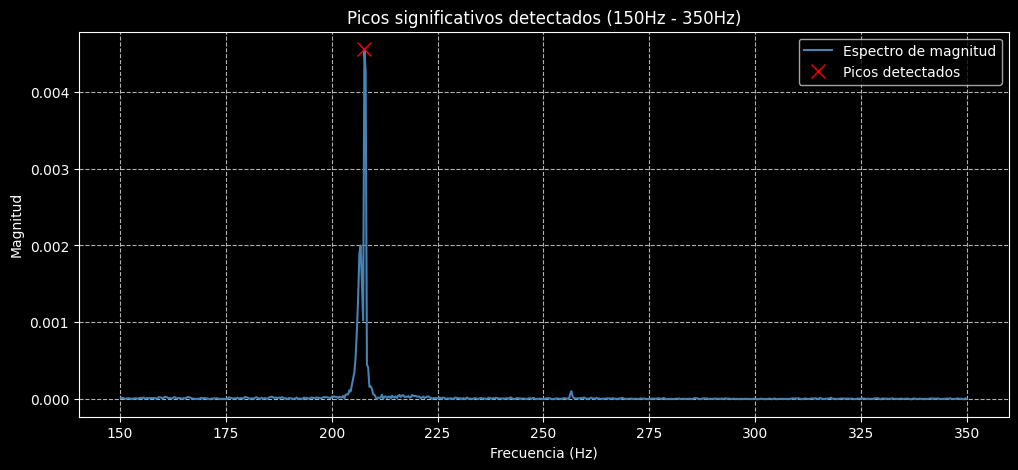

In [14]:
from scipy.signal import find_peaks

# --- CONFIGURACIÓN DEL USUARIO ---
# Define aquí el rango de frecuencia que te interesa (en Hz)
FREQ_MIN = 150   
FREQ_MAX = 350 

# Define el umbral de prominencia (qué tan "alto" debe ser el pico respecto a sus vecinos)
# Un valor de 0.01 es un buen inicio para señales normalizadas
PROMINENCE_THRESHOLD = 0.003 
# ---------------------------------

# 1. Filtrar los datos dentro del rango especificado
mask = (frequencies >= FREQ_MIN) & (frequencies <= FREQ_MAX)
freq_range = frequencies[mask]
mag_range = magnitude[mask]

# 2. Encontrar los picos significativos
# distance: evita encontrar picos demasiado juntos (opcional)
peaks_indices, properties = find_peaks(mag_range, prominence=PROMINENCE_THRESHOLD)

# 3. Extraer valores de los picos encontrados
peaks_freqs = freq_range[peaks_indices]
peaks_mags = mag_range[peaks_indices]

# 4. Mostrar resultados
print(f"🔎 Análisis en el rango {FREQ_MIN}Hz - {FREQ_MAX}Hz:")
if len(peaks_freqs) > 0:
    print(f"Se encontraron {len(peaks_freqs)} picos significativos:")
    for i, (f, m) in enumerate(zip(peaks_freqs, peaks_mags)):
        print(f"  Pico {i+1}: {f:8.2f} Hz (Magnitud: {m:.4f})")
else:
    print("No se encontraron picos que superen el umbral de prominencia.")

# 5. Visualización del rango con los picos marcados
plt.figure(figsize=(12, 5))
plt.plot(freq_range, mag_range, label="Espectro de magnitud", color='steelblue')
plt.plot(peaks_freqs, peaks_mags, "x", label="Picos detectados", color='red', markersize=10)

plt.title(f"Picos significativos detectados ({FREQ_MIN}Hz - {FREQ_MAX}Hz)")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## Todos los audios

In [24]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from pydub import AudioSegment
from scipy.io import wavfile
import warnings

warnings.filterwarnings('ignore')

# 1. Identificar archivos MP3 en la carpeta actual
# El patrón busca archivos que empiecen por 'C' seguidos de números y 'T'
audio_files = glob.glob("C*T*.mp3")
audio_files.sort() # Ordenar para procesar en orden (C1T0, C1T1...)

print(f"🎵 Se encontraron {len(audio_files)} archivos para procesar:")
print(audio_files)

# Carpeta de salida para las gráficas
OUTPUT_FOLDER = "resultados_fourier"
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

🎵 Se encontraron 42 archivos para procesar:
['C1 T0.mp3', 'C1 T1.mp3', 'C1 T2.mp3', 'C1 T3.mp3', 'C1 T4.mp3', 'C1 T5.mp3', 'C1 T6.mp3', 'C2 T0.mp3', 'C2 T1.mp3', 'C2 T2.mp3', 'C2 T3.mp3', 'C2 T4.mp3', 'C2 T5.mp3', 'C2 T6.mp3', 'C3 T0.mp3', 'C3 T1.mp3', 'C3 T2.mp3', 'C3 T3.mp3', 'C3 T4.mp3', 'C3 T5.mp3', 'C3 T6.mp3', 'C4 T0.mp3', 'C4 T1.mp3', 'C4 T2.mp3', 'C4 T3.mp3', 'C4 T4.mp3', 'C4 T5.mp3', 'C4 T6.mp3', 'C5 T0.mp3', 'C5 T1.mp3', 'C5 T2.mp3', 'C5 T3.mp3', 'C5 T4.mp3', 'C5 T5.mp3', 'C5 T6.mp3', 'C6 T0.mp3', 'C6 T1.mp3', 'C6 T2.mp3', 'C6 T3.mp3', 'C6 T4.mp3', 'C6 T5.mp3', 'C6 T6.mp3']


Creating a new notebook:
* **Import Required Libraries**
* **List Audio Files in Tensión Folder**
* **Load an Audio File**
* **Perform Fourier Transform on Audio**
* **Plot the Frequency Spectrum**
* **Process All Audio Files in the Folder**



In [25]:
def procesar_audio_guitarra(file_path):
    name = os.path.splitext(file_path)[0]
    temp_wav = f"{name}_temp.wav"
    
    try:
        # Cargar y convertir a WAV temporal
        audio = AudioSegment.from_file(file_path)
        audio.export(temp_wav, format="wav")
        
        # Leer datos
        sample_rate, data = wavfile.read(temp_wav)
        if data.ndim == 2: data = data.mean(axis=1)
        
        # Normalización y FFT
        signal = data.astype(np.float64) / (np.iinfo(data.dtype).max if np.issubdtype(data.dtype, np.integer) else 1.0)
        N = len(signal)
        frequencies = np.fft.fftfreq(N, d=1/sample_rate)[:N//2]
        magnitude = (2/N) * np.abs(np.fft.fft(signal * np.hanning(N))[:N//2])
        
        # Detectar top 3 frecuencias dominantes
        top_indices = np.argsort(magnitude)[::-1][:3]
        top_freqs = frequencies[top_indices]
        
        # Graficar
        plt.style.use('dark_background')
        fig, ax = plt.subplots(figsize=(10, 4))
        mask = frequencies <= 1500 # Filtro para ver armónicos musicales
        ax.plot(frequencies[mask], magnitude[mask], color='#00e5ff')
        ax.set_title(f"Análisis: {name} | Freqs Dominantes: {top_freqs[0]:.2f}, {top_freqs[1]:.2f}, {top_freqs[2]:.2f} Hz")
        ax.set_xlabel("Frecuencia (Hz)")
        ax.set_ylabel("Magnitud")
        
        # Guardar gráfica
        plt.savefig(f"{OUTPUT_FOLDER}/{name}_espectro.png")
        plt.close() # Cerrar para no saturar la memoria
        
        # Limpieza
        os.remove(temp_wav)
        return top_freqs
        
    except Exception as e:
        if os.path.exists(temp_wav): os.remove(temp_wav)
        print(f"❌ Error en {file_path}: {e}")
        return None

In [26]:
resultados = {}

print("🚀 Iniciando procesamiento...")
for file in audio_files:
    freqs = procesar_audio_guitarra(file)
    if freqs is not None:
        resultados[file] = freqs
        print(f"✅ Procesado: {file} -> Top 3: {freqs[0]:.2f}, {freqs[1]:.2f}, {freqs[2]:.2f} Hz")

print(f"\n✨ ¡Listo! Las gráficas se guardaron en la carpeta: '{OUTPUT_FOLDER}'")

# Mostrar resumen rápido
print("\nRESUMEN DE FRECUENCIAS:")
for audio, freqs in resultados.items():
    print(f"{audio:15} | {freqs[0]:8.2f} Hz | {freqs[1]:8.2f} Hz | {freqs[2]:8.2f} Hz")

🚀 Iniciando procesamiento...
✅ Procesado: C1 T0.mp3 -> Top 3: 330.33, 330.96, 329.71 Hz
✅ Procesado: C1 T1.mp3 -> Top 3: 350.53, 350.99, 350.07 Hz
✅ Procesado: C1 T2.mp3 -> Top 3: 279.08, 278.68, 557.36 Hz
✅ Procesado: C1 T3.mp3 -> Top 3: 392.84, 392.26, 393.43 Hz
✅ Procesado: C1 T4.mp3 -> Top 3: 415.39, 415.89, 833.26 Hz
✅ Procesado: C1 T5.mp3 -> Top 3: 440.09, 440.45, 439.73 Hz
✅ Procesado: C1 T6.mp3 -> Top 3: 466.05, 466.67, 934.58 Hz
✅ Procesado: C2 T0.mp3 -> Top 3: 497.41, 248.70, 247.82 Hz
✅ Procesado: C2 T1.mp3 -> Top 3: 263.46, 263.94, 262.98 Hz
✅ Procesado: C2 T2.mp3 -> Top 3: 279.12, 278.70, 557.82 Hz
✅ Procesado: C2 T3.mp3 -> Top 3: 296.09, 295.63, 592.18 Hz
✅ Procesado: C2 T4.mp3 -> Top 3: 313.64, 313.98, 313.29 Hz
✅ Procesado: C2 T5.mp3 -> Top 3: 331.44, 331.85, 331.03 Hz
✅ Procesado: C2 T6.mp3 -> Top 3: 352.00, 352.56, 351.44 Hz
✅ Procesado: C3 T0.mp3 -> Top 3: 196.42, 195.96, 196.87 Hz
✅ Procesado: C3 T1.mp3 -> Top 3: 417.29, 208.41, 417.76 Hz
✅ Procesado: C3 T2.mp3 -> T

In [28]:
import re

# Convertir resultados a filas con cuerda y traste desde el nombre de archivo
data_rows = []
for file_path, freqs in resultados.items():
    nombre = os.path.basename(file_path)
    match = re.search(r"C\s*(\d+)\s*T\s*(\d+)\.mp3$", nombre, re.IGNORECASE)
    if match:
        cuerda = int(match.group(1))
        traste = int(match.group(2))
        data_rows.append((cuerda, traste, freqs))
    else:
        print(f"⚠️ Nombre no reconocido para guardar datos: {nombre}")

print(f"✅ Se procesaron {len(data_rows)} archivos para exportación")

✅ Se procesaron 42 archivos para exportación


In [29]:
# Exportar datos a archivos .dat
if not data_rows:
    print("❌ No hay datos válidos para exportar.")
else:
    data_rows.sort()
    output_dat = os.path.join(OUTPUT_FOLDER, "frecuencias_por_traste.dat")

    # Archivo consolidado con todas las frecuencias
    with open(output_dat, "w", encoding="utf-8") as f:
        f.write("# cuerda traste freq1_hz freq2_hz freq3_hz\n")
        for cuerda, traste, freqs in data_rows:
            f.write(f"{cuerda} {traste} {freqs[0]:.6f} {freqs[1]:.6f} {freqs[2]:.6f}\n")

    print(f"✅ Datos consolidados guardados en: {output_dat}")

    # Guardar un archivo .dat individual para cada cuerda
    for cuerda in sorted({c for c, _, _ in data_rows}):
        rows = [(t, f) for c, t, f in data_rows if c == cuerda]
        rows.sort()
        output_dat_cuerda = os.path.join(OUTPUT_FOLDER, f"frecuencias_cuerda_{cuerda}.dat")
        with open(output_dat_cuerda, "w", encoding="utf-8") as f:
            f.write("# traste freq1_hz freq2_hz freq3_hz\n")
            for traste, freqs in rows:
                f.write(f"{traste} {freqs[0]:.6f} {freqs[1]:.6f} {freqs[2]:.6f}\n")
        print(f"✅ Datos cuerda {cuerda} guardados en: {output_dat_cuerda}")

✅ Datos consolidados guardados en: resultados_fourier/frecuencias_por_traste.dat
✅ Datos cuerda 1 guardados en: resultados_fourier/frecuencias_cuerda_1.dat
✅ Datos cuerda 2 guardados en: resultados_fourier/frecuencias_cuerda_2.dat
✅ Datos cuerda 3 guardados en: resultados_fourier/frecuencias_cuerda_3.dat
✅ Datos cuerda 4 guardados en: resultados_fourier/frecuencias_cuerda_4.dat
✅ Datos cuerda 5 guardados en: resultados_fourier/frecuencias_cuerda_5.dat
✅ Datos cuerda 6 guardados en: resultados_fourier/frecuencias_cuerda_6.dat


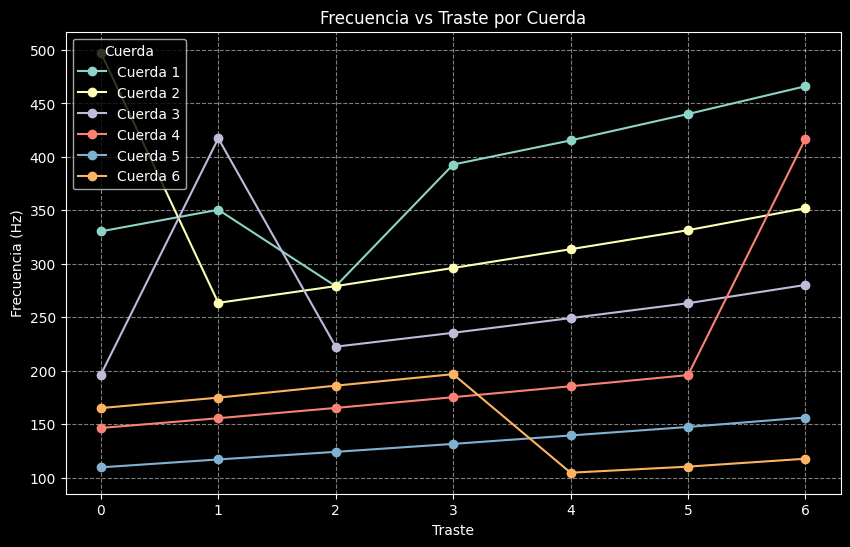

✅ Gráfica guardada en: resultados_fourier/frecuencia_vs_traste_por_cuerda.png


In [30]:
# Graficar frecuencia vs traste para cada cuerda (usando la frecuencia dominante)
plt.figure(figsize=(10, 6))
for cuerda in sorted({c for c, _, _ in data_rows}):
    rows = [(t, f[0]) for c, t, f in data_rows if c == cuerda]
    rows.sort()
    trastes = [t for t, _ in rows]
    frecuencias = [f for _, f in rows]
    plt.plot(trastes, frecuencias, marker="o", label=f"Cuerda {cuerda}")

plt.title("Frecuencia vs Traste por Cuerda")
plt.xlabel("Traste")
plt.ylabel("Frecuencia (Hz)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Cuerda")
plt.xticks(sorted({t for _, t, _ in data_rows}))

grafica_path = os.path.join(OUTPUT_FOLDER, "frecuencia_vs_traste_por_cuerda.png")
plt.savefig(grafica_path)
plt.show()

print(f"✅ Gráfica guardada en: {grafica_path}")

## Tensión


In [5]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydub import AudioSegment
from scipy.io import wavfile
from scipy.signal import find_peaks
import warnings

warnings.filterwarnings('ignore')

# --- CONFIGURACIÓN DE RUTAS ---
CARPETA_AUDIOS = "Tensión" 
OUTPUT_FOLDER = "analisis_fourier_Tension"
# ------------------------------

if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)

# Cambiamos el patrón a "*.mp3" para que tome TODOS los audios de la carpeta
patron = os.path.join(CARPETA_AUDIOS, "*.mp3")
audio_files = glob.glob(patron)
audio_files.sort()

if len(audio_files) == 0:
    print(f"❌ No se encontraron audios en la carpeta '{CARPETA_AUDIOS}'.")
    # Imprime la ruta absoluta para estar seguros de dónde está buscando el script
    print(f"Ruta buscada: {os.path.abspath(CARPETA_AUDIOS)}")
else:
    print(f"🎵 Se encontraron {len(audio_files)} archivos en '{CARPETA_AUDIOS}' para procesar.")
    print(f"Ejemplo de archivos encontrados: {audio_files[:3]}")

🎵 Se encontraron 24 archivos en 'Tensión' para procesar.
Ejemplo de archivos encontrados: ['Tensión/-180 C1.mp3', 'Tensión/-180 C2.mp3', 'Tensión/-180 C3.mp3']


In [6]:
def analizar_picos_fourier(path_archivo):
    # Extraemos solo el nombre del archivo sin la extensión y sin la carpeta
    nombre_archivo = os.path.basename(path_archivo)
    nombre_base = os.path.splitext(nombre_archivo)[0]
    
    # El temporal lo creamos en la carpeta de resultados para no ensuciar 'Tensión'
    temp_wav = os.path.join(OUTPUT_FOLDER, f"temp_{nombre_base}.wav")
    
    # 1. Conversión
    audio = AudioSegment.from_file(path_archivo)
    audio.export(temp_wav, format="wav")
    
    # 2. Lectura y Normalización
    fs, data = wavfile.read(temp_wav)
    if data.ndim > 1: data = data.mean(axis=1)
    
    x = data / (np.iinfo(data.dtype).max if np.issubdtype(data.dtype, np.integer) else 1.0)
    n = len(x)
    
    # 3. FFT
    frecuencias = np.fft.fftfreq(n, d=1/fs)[:n//2]
    ventana = np.hanning(n)
    fft_mag = (2/n) * np.abs(np.fft.fft(x * ventana)[:n//2])
    
    # 4. Encontrar picos
    picos_idx, propiedades = find_peaks(fft_mag, height=0.005, distance=30)
    alturas = propiedades['peak_heights']
    
    top3_indices = picos_idx[np.argsort(alturas)[-3:][::-1]]
    top3_freqs = np.sort(frecuencias[top3_indices])
    
    # 5. Gráfica
    plt.style.use('dark_background')
    plt.figure(figsize=(10, 4))
    mask = frecuencias <= 1500
    plt.plot(frecuencias[mask], fft_mag[mask], color='#7cfc00', lw=1) # Color verde para variar
    
    for idx in top3_indices:
        plt.plot(frecuencias[idx], fft_mag[idx], "ro")
        plt.annotate(f"{frecuencias[idx]:.1f} Hz", (frecuencias[idx], fft_mag[idx]), 
                     textcoords="offset points", xytext=(0,10), ha='center', color='white')
    
    plt.title(f"Análisis Tensión: {nombre_base}")
    plt.xlabel("Frecuencia (Hz)")
    plt.savefig(os.path.join(OUTPUT_FOLDER, f"{nombre_base}_picos.png"))
    plt.close()
    
    if os.path.exists(temp_wav):
        os.remove(temp_wav)
    
    return list(top3_freqs) + [0]*(3-len(top3_freqs))

In [7]:
data_final = []

for archivo in audio_files:
    try:
        f1, f2, f3 = analizar_picos_fourier(archivo)
        data_final.append({
            "Cuerda_Traste": os.path.basename(archivo),
            "Freq_1": f1,
            "Freq_2": f2,
            "Freq_3": f3
        })
        print(f"✅ Analizado: {os.path.basename(archivo)}")
    except Exception as e:
        print(f"❌ Error en {archivo}: {e}")

df_tension = pd.DataFrame(data_final)
df_tension.to_csv(os.path.join(OUTPUT_FOLDER, "resultados_tension.csv"), index=False)
display(df_tension)

✅ Analizado: -180 C1.mp3
✅ Analizado: -180 C2.mp3
✅ Analizado: -180 C3.mp3
✅ Analizado: -180 C4.mp3
✅ Analizado: -180 C5.mp3
✅ Analizado: -180 C6.mp3
✅ Analizado: -90 C1.mp3
✅ Analizado: -90 C2.mp3
✅ Analizado: -90 C3.mp3
✅ Analizado: -90 C4.mp3
✅ Analizado: -90 C5.mp3
✅ Analizado: -90 C6.mp3
✅ Analizado: 180 C1.mp3
✅ Analizado: 180 C2.mp3
✅ Analizado: 180 C3.mp3
✅ Analizado: 180 C4.mp3
✅ Analizado: 180 C5.mp3
✅ Analizado: 180 C6.mp3
✅ Analizado: 90 C1.mp3
✅ Analizado: 90 C2.mp3
✅ Analizado: 90 C3.mp3
✅ Analizado: 90 C4.mp3
✅ Analizado: 90 C5.mp3
✅ Analizado: 90 C6.mp3


,Cuerda_Traste,Freq_1,Freq_2,Freq_3
0,-180 C1.mp3,318.019467,0.000000,0.000000
1,-180 C2.mp3,238.509317,475.031056,0.000000
2,-180 C3.mp3,188.364888,377.201869,0.000000
3,-180 C4.mp3,142.731891,285.909123,428.641013
4,-180 C5.mp3,106.506946,213.251101,320.469674
5,-180 C6.mp3,80.748580,161.497160,242.761705
6,-90 C1.mp3,323.942989,0.000000,0.000000
7,-90 C2.mp3,244.310392,487.386893,0.000000
8,-90 C3.mp3,191.376769,383.913397,576.836645
9,-90 C4.mp3,144.433601,289.467758,433.601081
